# Import libraries and artifacts

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

# Relative path from notebooks/ to artifacts/
ARTIFACTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'artifacts')
ARTIFACTS_DIR = os.path.normpath(ARTIFACTS_DIR)


print(f"Artifacts Exists: {os.path.exists(ARTIFACTS_DIR)}")

# Helper to resolve artifact paths
def artifact(filename):
    return os.path.join(ARTIFACTS_DIR, filename)

Artifacts Exists: True


## Best Model Summary

In [3]:
summary_path = artifact('best_fine_tuned_model.json')

if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        summary = json.load(f)

    print("=" * 45)
    print("   BEST MODEL SUMMARY")
    print("=" * 45)
    print(f"  Best Model   : {summary['best_model']}")
    print(f"  Test Accuracy: {summary['accuracy']:.2%}")
    print(f"  Classes      : {summary['classes']}")
    print(f"  Train samples: {summary['training_samples']}")
    print(f"  Val samples  : {summary['validation_samples']}")
    print(f"  Test samples : {summary['test_samples']}")
    print("=" * 45)
else:
    print(f"[WARNING] best_fine_tuned_model.json not found at:\n  {summary_path}")

   BEST MODEL SUMMARY
  Best Model   : MobileNetV2
  Test Accuracy: 96.02%
  Classes      : ['buffalo', 'elephant', 'rhino', 'zebra']
  Train samples: 1052
  Val samples  : 226
  Test samples : 226


## Model Comparison Table

In [4]:
csv_path = artifact('fine_tuning_comparison.csv')

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # Drop internal numeric column if present
    display_df = df.drop(columns=[c for c in df.columns if 'Value' in c], errors='ignore')

    display(
        display_df.style
        .set_caption("Fine-Tuned Model Comparison")
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left')]
        }])
        .hide(axis='index')
    )
else:
    print(f"[WARNING] fine_tuning_comparison.csv not found at:\n  {csv_path}")

Model,Test Accuracy
MobileNetV2,96.02%
ResNet50,46.02%
EfficientNetB0,25.22%


# Accuracy and loss curves

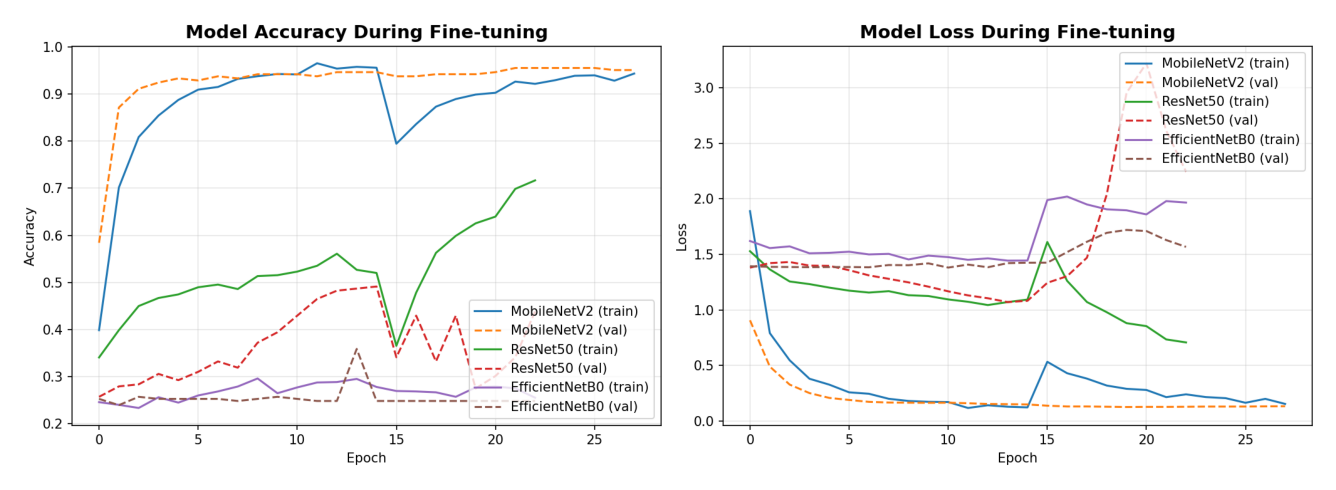

In [5]:
history_path = artifact('fine_tuning_history.png')

if os.path.exists(history_path):
    img = mpimg.imread(history_path)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] fine_tuning_history.png not found at:\n  {history_path}")

## Model Accuracy Comparison

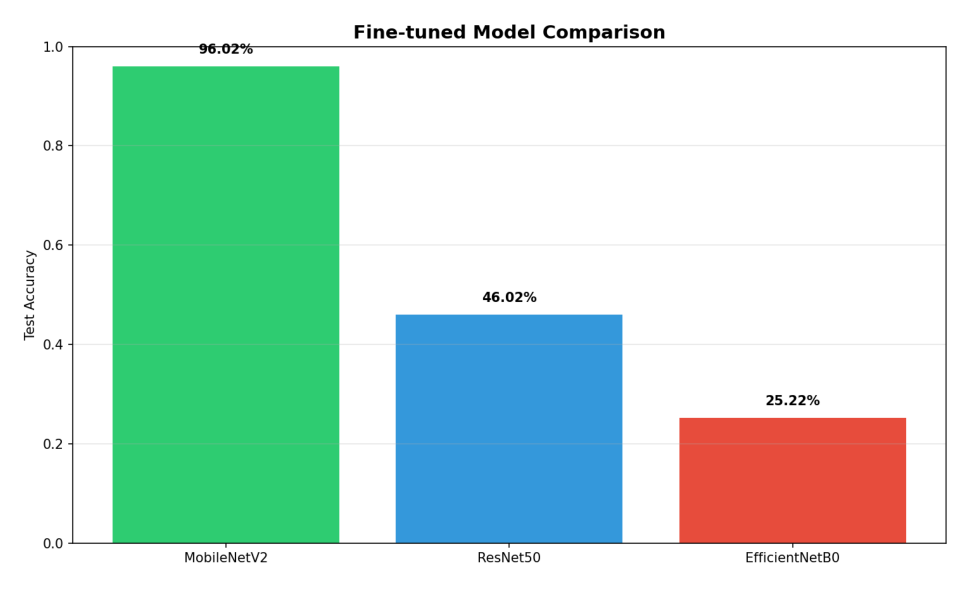

In [6]:
comparison_path = artifact('fine_tuning_comparison.png')

if os.path.exists(comparison_path):
    img = mpimg.imread(comparison_path)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] fine_tuning_comparison.png not found at:\n  {comparison_path}")

## Confusion Matrix — Best Model

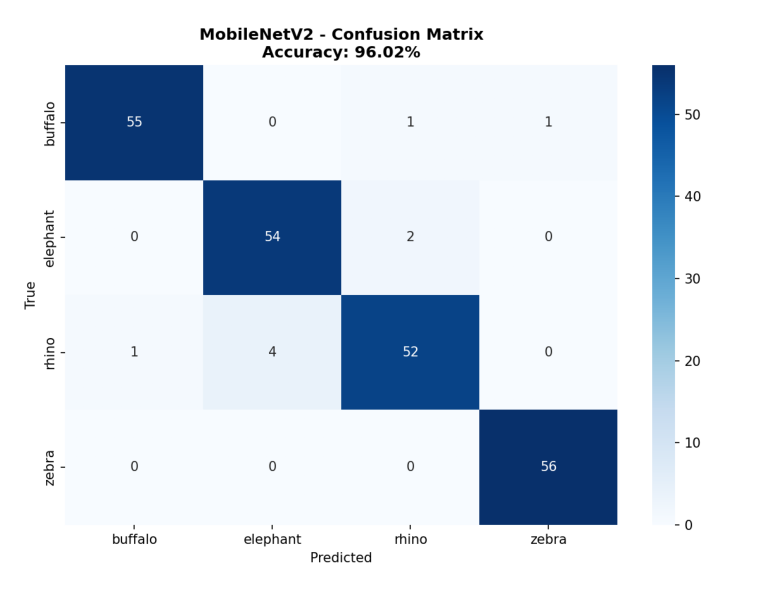

In [7]:
# Determine best model name from JSON, or fall back to scanning artifacts dir
best_model_name = None

if os.path.exists(summary_path):
    with open(summary_path, 'r') as f:
        best_model_name = json.load(f)['best_model']
else:
    # Fallback: look for any confusion matrix png in artifacts
    for fname in os.listdir(ARTIFACTS_DIR):
        if fname.endswith('_fine_tuned_confusion.png'):
            best_model_name = fname.replace('_fine_tuned_confusion.png', '')
            print(f"Inferred best model from filename: {best_model_name}")
            break

if best_model_name:
    cm_path = artifact(f'{best_model_name}_fine_tuned_confusion.png')
    if os.path.exists(cm_path):
        img = mpimg.imread(cm_path)
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"[WARNING] Confusion matrix not found at:\n  {cm_path}")
else:
    print("[WARNING] Could not determine best model name. Ensure best_fine_tuned_model.json exists.")